In [19]:
# Environment configure
import sys
import os

if "google.colab" in sys.modules:
    is_colab = True
    print("Running in Google Colab")
    from google.colab import drive
    drive.mount("/content/drive")
    path = "/content/drive/MyDrive/Colab Notebooks/JCMDSC_adversarial"
    %cd $path
    os.getcwd()

    from IPython.display import Image, display
else:
    print("Not running in Goolge Colab")
    path = r"D:\repos\Joint-Coding-Modulation-for-Digital-Semantic-Communication"

Not running in Goolge Colab


In [20]:
# In-notebook implementation
# This cell defines the full model/training code so you can run everything directly in this notebook (local or Colab).

In [21]:
# path = "/content/drive/MyDrive/Colab Notebooks/JCMDSC_adversarial"
%cd $path
os.getcwd()

D:\repos\Joint-Coding-Modulation-for-Digital-Semantic-Communication


'D:\\repos\\Joint-Coding-Modulation-for-Digital-Semantic-Communication'

In [22]:
# Core implementation (inlined from top-level .py files)
import os
import math
import random
from types import SimpleNamespace

import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torch.nn.functional import gumbel_softmax
from torch.nn import init
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from skimage.metrics import peak_signal_noise_ratio as comp_psnr
from skimage.metrics import structural_similarity as comp_ssim
from skimage.metrics import mean_squared_error as comp_mse


def init_seeds(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if seed == 42:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def save_checkpoint(state, filename="my_checkpoint.pth.tar"):
    print("=>Saving checkpoint")
    torch.save(state, filename)


def count_percentage(code, mod, epoch, snr, channel_use, tradeoff_h):
    if mod == "4qam" or mod == "bpsk":
        return

    code = code.reshape(-1)
    index = [i for i in range(len(code))]
    random.shuffle(index)
    code = code[index]
    code = code.reshape(-1, 2).cpu()

    if mod == "16qam":
        i_point = torch.tensor([-3, -1, 1, 3])
        order = 16
    elif mod == "64qam":
        i_point = torch.tensor([-7, -5, -3, -1, 1, 3, 5, 7])
        order = 64
    else:
        return

    i_grid, q_grid = torch.meshgrid(i_point, i_point, indexing="ij")
    mapping = torch.cat((i_grid.unsqueeze(-1), q_grid.unsqueeze(-1)), dim=2).reshape(order, 2)
    per_s = []
    fig = plt.figure(dpi=300)
    ax = Axes3D(fig)
    fig.add_axes(ax)
    for i in range(order):
        temp = torch.sum(torch.abs(code - mapping[i, :]), dim=1)
        num = code.shape[0] - torch.count_nonzero(temp).item()
        per = num / code.shape[0]
        per_s.append(per)
    per_s = torch.tensor(per_s).cpu()
    height = np.zeros_like(per_s)
    width = depth = 0.3
    surf = ax.bar3d(i_grid.ravel(), q_grid.ravel(), height, width, depth, per_s, zsort="average")
    surf._facecolors2d = surf._facecolor3d
    surf._edgecolors2d = surf._edgecolor3d
    file_name = "./cons_fig/" + "{}_{}_{}_{}".format(mod, snr, channel_use, tradeoff_h)
    if not os.path.exists(file_name):
        os.makedirs(file_name)
    fig.savefig(file_name + "/{}".format(epoch))
    plt.close()

    if mod == "64qam":
        fig = plt.figure(dpi=300)
        for k in range(order):
            plt.scatter(mapping[k, 0], mapping[k, 1], s=1000 * per_s[k], color="b")
        fig.savefig(file_name + "/scatter_{}".format(epoch))
        plt.close()


def PSNR(tensor_org, tensor_trans):
    total_psnr = 0
    origin = ((tensor_org + 1) / 2).cpu().numpy()
    trans = ((tensor_trans + 1) / 2).cpu().numpy()
    for i in range(np.size(trans, 0)):
        psnr = 0
        for j in range(np.size(trans, 1)):
            psnr_temp = comp_psnr(origin[i, j, :, :], trans[i, j, :, :])
            psnr = psnr + psnr_temp
        psnr /= 3
        total_psnr += psnr
    return total_psnr


def SSIM(tensor_org, tensor_trans):
    total_ssim = 0
    origin = tensor_org.cpu().numpy()
    trans = tensor_trans.cpu().numpy()
    for i in range(np.size(trans, 0)):
        ssim = 0
        for j in range(np.size(trans, 1)):
            ssim_temp = comp_ssim(origin[i, j, :, :], trans[i, j, :, :], data_range=1.0)
            ssim = ssim + ssim_temp
        ssim /= 3
        total_ssim += ssim
    return total_ssim


def MSE(tensor_org, tensor_trans):
    origin = ((tensor_org + 1) / 2).cpu().numpy()
    trans = ((tensor_trans + 1) / 2).cpu().numpy()
    mse = np.mean((origin - trans) ** 2)
    return mse * tensor_org.shape[0]


def normalize(x, power=1):
    power_emp = torch.mean(x ** 2)
    x = (power / power_emp) ** 0.5 * x
    return power_emp, x


class DepthToSpace(torch.nn.Module):
    def __init__(self, block_size):
        super().__init__()
        self.bs = block_size

    def forward(self, x):
        n, c, h, w = x.size()
        x = x.view(n, self.bs, self.bs, c // (self.bs ** 2), h, w)
        x = x.permute(0, 3, 4, 1, 5, 2).contiguous()
        x = x.view(n, c // (self.bs ** 2), h * self.bs, w * self.bs)
        return x


def awgn(snr, x, device):
    n = 1 / (10 ** (snr / 10))
    sqrt_n = n ** 0.5
    noise = torch.randn_like(x) * sqrt_n
    noise = noise.to(device)
    x_hat = x + noise
    return x_hat


class ResidualBlock(nn.Module):
    def __init__(self, inchannel, outchannel, stride=1):
        super(ResidualBlock, self).__init__()
        self.left = nn.Sequential(
            nn.Conv2d(inchannel, outchannel, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(outchannel),
            nn.PReLU(),
            nn.Conv2d(outchannel, outchannel, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(outchannel),
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or inchannel != outchannel:
            self.shortcut = nn.Sequential(
                nn.Conv2d(inchannel, outchannel, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(outchannel),
            )
        self.prelu = nn.PReLU()

    def forward(self, x):
        out = self.left(x)
        out += self.shortcut(x)
        out = self.prelu(out)
        return out


class Encoder(nn.Module):
    def __init__(self, config):
        super(Encoder, self).__init__()
        self.config = config
        self.inchannel = 64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.PReLU(),
        )
        self.layer1 = self.make_layer(ResidualBlock, 64, 1, stride=1)
        self.layer2 = self.make_layer(ResidualBlock, 128, 1, stride=2)
        self.layer3 = self.make_layer(ResidualBlock, 256, 2, stride=2)
        if config.mod_method == "bpsk":
            self.layer4 = self.make_layer(ResidualBlock, config.channel_use, 2, stride=2)
        else:
            self.layer4 = self.make_layer(ResidualBlock, config.channel_use * 2, 2, stride=2)

    def make_layer(self, block, channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.inchannel, channels, stride))
            self.inchannel = channels
        return nn.Sequential(*layers)

    def forward(self, x):
        z0 = self.conv1(x)
        z1 = self.layer1(z0)
        z2 = self.layer2(z1)
        z3 = self.layer3(z2)
        z4 = self.layer4(z3)
        return z4


class Decoder_Recon(nn.Module):
    def __init__(self, config):
        super(Decoder_Recon, self).__init__()
        self.config = config

        if config.mod_method == "bpsk":
            input_channel = int(config.channel_use / (4 * 4))
        else:
            input_channel = int(config.channel_use * 2 / (4 * 4))

        self.conv1 = nn.Sequential(
            nn.Conv2d(input_channel, 256, 1, 1, 0),
            nn.PReLU(),
        )

        self.inchannel = 256

        self.layer1 = nn.Sequential(
            self.make_layer(ResidualBlock, 256, 2, stride=1),
            nn.PReLU(),
        )

        self.layer2 = nn.Sequential(
            self.make_layer(ResidualBlock, 256, 2, stride=1),
            nn.PReLU(),
        )

        self.depth_to_space1 = DepthToSpace(4)

        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 128, 1, 1, 0),
            nn.PReLU(),
        )

        self.inchannel = 128

        self.layer3 = nn.Sequential(
            self.make_layer(ResidualBlock, 128, 2, stride=1),
            nn.PReLU(),
        )

        self.depth_to_space2 = DepthToSpace(2)

        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 3, 1, 1, 0),
        )

    def make_layer(self, block, channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.inchannel, channels, stride))
            self.inchannel = channels
        return nn.Sequential(*layers)

    def forward(self, z):
        z0 = self.conv1(z.reshape(z.shape[0], -1, 4, 4))
        z1 = self.layer1(z0)
        z2 = self.layer2(z1)
        z3 = self.depth_to_space1(z2)
        z4 = self.conv2(z3)
        z5 = self.layer3(z4)
        z5 = self.depth_to_space2(z5)
        z6 = self.conv3(z5)
        return z6


class Decoder_Class(nn.Module):
    def __init__(self, half_width, layer_width):
        super(Decoder_Class, self).__init__()
        self.layer_width = layer_width
        self.half_width = half_width
        self.fc_spinal_layer1 = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(self.half_width, self.layer_width),
            nn.PReLU(),
        )
        self.fc_spinal_layer2 = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(self.half_width + self.layer_width, self.layer_width),
            nn.PReLU(),
        )
        self.fc_spinal_layer3 = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(self.half_width + self.layer_width, self.layer_width),
            nn.PReLU(),
        )
        self.fc_spinal_layer4 = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(self.half_width + self.layer_width, self.layer_width),
            nn.PReLU(),
        )
        self.last_fc = nn.Linear(self.layer_width * 4, 10)

    def forward(self, z):
        x1 = self.fc_spinal_layer1(z[:, 0:self.half_width])
        x2 = self.fc_spinal_layer2(torch.cat([z[:, self.half_width:2 * self.half_width], x1], dim=1))
        x3 = self.fc_spinal_layer3(torch.cat([z[:, 0:self.half_width], x2], dim=1))
        x4 = self.fc_spinal_layer4(torch.cat([z[:, self.half_width:2 * self.half_width], x3], dim=1))
        x = torch.cat([x1, x2], dim=1)
        x = torch.cat([x, x3], dim=1)
        x = torch.cat([x, x4], dim=1)

        y_class = self.last_fc(x)
        return y_class


def canonical_mod_method(mod_method):
    method = str(mod_method).strip().lower()
    while len(method) >= 2 and (
        (method[0] == "'" and method[-1] == "'") or
        (method[0] == '"' and method[-1] == '"')
    ):
        method = method[1:-1].strip().lower()
    aliases = {
        "qpsk": "4qam",
        "4-qam": "4qam",
        "16-qam": "16qam",
        "64-qam": "64qam",
    }
    return aliases.get(method, method)


def modulation(logits, device, mod_method="bpsk"):
    mod_method = canonical_mod_method(mod_method)

    discrete_code = gumbel_softmax(logits, hard=True, tau=1.5)

    if mod_method == "bpsk":
        output = discrete_code[:, :, 0] * (-1) + discrete_code[:, :, 1] * 1
    elif mod_method == "4qam":
        const = [1, -1]
        const = torch.tensor(const).to(device)
        temp = discrete_code * const
        output = torch.sum(temp, dim=2)
    elif mod_method == "16qam":
        const = [-3, -1, 1, 3]
        const = torch.tensor(const).to(device)
        temp = discrete_code * const
        output = torch.sum(temp, dim=2)
    elif mod_method == "64qam":
        const = [-7, -5, -3, -1, 1, 3, 5, 7]
        const = torch.tensor(const).to(device)
        temp = discrete_code * const
        output = torch.sum(temp, dim=2)
    else:
        raise ValueError("Modulation method not defined.")

    return output


class JCM(nn.Module):
    def __init__(self, config, device):
        super(JCM, self).__init__()
        self.config = config
        self.device = device
        self.mod_method = canonical_mod_method(self.config.mod_method)

        if self.mod_method == "bpsk":
            self.num_category = 2
        elif self.mod_method == "4qam":
            self.num_category = 2
        elif self.mod_method == "16qam":
            self.num_category = 4
        elif self.mod_method == "64qam":
            self.num_category = 8
        else:
            raise ValueError(
                f"Unsupported mod_method: {self.config.mod_method}. "
                "Use one of: bpsk, 4qam, 16qam, 64qam."
            )

        self.encoder = Encoder(self.config)

        if self.mod_method == "bpsk":
            self.prob_convs = nn.Sequential(
                nn.Linear(config.channel_use * 4 * 4, config.channel_use * self.num_category),
                nn.ReLU(),
            )
        else:
            self.prob_convs = nn.Sequential(
                nn.Linear(config.channel_use * 2 * 4 * 4, config.channel_use * 2 * self.num_category),
                nn.ReLU(),
            )

        self.decoder_recon = Decoder_Recon(self.config)

        if self.mod_method == "bpsk":
            self.decoder_class = Decoder_Class(int(config.channel_use / 2), int(config.channel_use / 8))
        else:
            self.decoder_class = Decoder_Class(int(config.channel_use * 2 / 2), int(config.channel_use * 2 / 8))

        self.initialize_weights()

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.xavier_normal_(m.weight, gain=1)
            elif isinstance(m, nn.Conv2d):
                init.xavier_uniform_(m.weight, gain=1)

    def reparameterize(self, probs):
        code = modulation(probs, self.device, self.mod_method)
        return code

    def forward(self, x):
        x_f = self.encoder(x).reshape(x.shape[0], -1)
        z = self.prob_convs(x_f).reshape(x.shape[0], -1, self.num_category)
        code = self.reparameterize(z)

        power, z = normalize(code)

        if self.config.mode == "train":
            z_hat = awgn(self.config.snr_train, z, self.device)
        if self.config.mode == "test":
            z_hat = awgn(self.config.snr_test, z, self.device)

        recon = self.decoder_recon(z_hat)
        r_class = self.decoder_class(z_hat)

        return code, z, z_hat, r_class, recon


class AnalogNet(nn.Module):
    def __init__(self, config, device):
        super(AnalogNet, self).__init__()
        self.config = config
        self.device = device

        self.encoder = Encoder(self.config)

        if self.config.mod_method == "bpsk":
            self.dimension = 1
        else:
            self.dimension = 2

        self.avepool = nn.AvgPool2d(4)

        self.decoder_class = Decoder_Class(
            int(config.channel_use / 2 * self.dimension),
            int(config.channel_use / 8 * self.dimension),
        )
        self.decoder_recon = Decoder_Recon(config)

    def forward(self, x):
        z = self.avepool(self.encoder(x)).reshape(x.shape[0], -1)
        power, z = normalize(z)

        if self.config.mode == "train":
            z_hat = awgn(self.config.snr_train, z, self.device)
        if self.config.mode == "test":
            z_hat = awgn(self.config.snr_test, z, self.device)

        y_class = self.decoder_class(z_hat)
        y_recon = self.decoder_recon(z_hat)
        return z, z_hat, y_class, y_recon


def EVAL(model, data_loader, device, config, epoch=0):
    model.eval()
    acc_total = 0
    mse_total = 0
    psnr_total = 0
    ssim_total = 0
    total = 0

    z_total = torch.zeros((10000, config.channel_use * 2))
    for batch_idx, (data, target) in enumerate(tqdm(data_loader)):
        data, target = data.to(device), target.to(device)
        total += len(target)

        with torch.no_grad():
            code, z, z_hat, pred, rec = model(data)
            if config.mode == "test" and (config.mod_method == "16qam" or config.mod_method == "64qam"):
                if batch_idx <= int(10000 / config.batch_size) - 1:
                    z_total[batch_idx * config.batch_size:(batch_idx + 1) * config.batch_size, :] = code
                elif batch_idx == int(10000 / config.batch_size):
                    z_total[int(10000 / config.batch_size) * config.batch_size:, :] = code
                    count_percentage(z_total, config.mod_method, -1, config.snr_train, config.channel_use, config.tradeoff_lambda)
            else:
                if batch_idx == 0:
                    count_percentage(code, config.mod_method, epoch, config.snr_train, config.channel_use, config.tradeoff_lambda)

        acc = (pred.data.max(1)[1] == target.data).float().sum()
        mse = MSE(data, rec)
        psnr = PSNR(data, rec)
        ssim = SSIM(data, rec)

        acc_total += acc
        mse_total += mse
        psnr_total += psnr
        ssim_total += ssim

    acc_total /= total
    mse_total /= total
    psnr_total /= total
    ssim_total /= total

    return acc_total, mse_total, psnr_total, ssim_total


def EVAL_analog(model, data_loader, device, config, epoch=0):
    model.eval()
    acc_total = 0
    mse_total = 0
    psnr_total = 0
    ssim_total = 0
    total = 0

    for batch_idx, (data, target) in enumerate(tqdm(data_loader)):
        data, target = data.to(device), target.to(device)
        total += len(target)

        with torch.no_grad():
            z, z_hat, pred, rec = model(data)

        acc = (pred.data.max(1)[1] == target.data).float().sum()
        mse = MSE(data, rec)
        psnr = PSNR(data, rec)
        ssim = SSIM(data, rec)

        acc_total += acc
        mse_total += mse
        psnr_total += psnr
        ssim_total += ssim

    acc_total /= total
    mse_total /= total
    psnr_total /= total
    ssim_total /= total

    return acc_total, mse_total, psnr_total, ssim_total


def train(config, net, train_iter, test_iter, device):
    learning_rate = config.lr
    epochs = config.train_iters

    ignored_params = list(map(id, net.prob_convs.parameters()))
    base_params = filter(lambda p: id(p) not in ignored_params, net.parameters())
    optimizer = torch.optim.Adam(
        [
            {"params": base_params},
            {"params": net.prob_convs.parameters(), "lr": learning_rate / 2},
        ],
        learning_rate,
    )

    loss_f1 = nn.CrossEntropyLoss()
    loss_f2 = nn.MSELoss()
    results = {"epoch": [], "acc": [], "mse": [], "psnr": [], "ssim": [], "loss": []}
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=config.train_iters + 1, T_mult=1, eta_min=1e-6, last_epoch=-1
    )

    best_acc = 0
    for epoch in range(epochs):
        net.train()
        epoch_loss = []
        acc_total_train = 0
        psnr_total_train = 0
        for i, (x, y) in enumerate(tqdm(train_iter)):
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            code, _, _, y_class, y_recon = net(x)

            loss_1 = loss_f1(y_class, y)
            loss_2 = loss_f2(y_recon, x)

            loss = loss_1 + config.tradeoff_lambda * loss_2

            loss.backward()
            optimizer.step()
            epoch_loss.append(loss.cpu().item())

            acc = (y_class.data.max(1)[1] == y.data).float().sum()
            acc_total_train += acc
            psnr = PSNR(x, y_recon.detach())
            psnr_total_train += psnr

        scheduler.step()

        loss = sum(epoch_loss) / len(epoch_loss)
        acc_train = acc_total_train / 50000
        psnr_train = psnr_total_train / 50000

        acc, mse, psnr, ssim = EVAL(net, test_iter, device, config, epoch)
        print(
            "epoch: {:d}, loss: {:.6f}, acc: {:.3f}, mse: {:.6f}, psnr: {:.3f}, ssim: {:.3f}, lr: {:.6f}".format(
                epoch, loss, acc, mse, psnr, ssim, optimizer.state_dict()["param_groups"][0]["lr"]
            )
        )
        print("train acc: {:.3f}".format(acc_train))
        print("train psnr: {:.3f}".format(psnr_train))

        acc_num = acc.detach().cpu().numpy()
        results["epoch"].append(epoch)
        results["loss"].append(loss)
        results["acc"].append(acc_num)
        results["mse"].append(mse)
        results["psnr"].append(psnr)
        results["ssim"].append(ssim)

        if (epochs - epoch) <= 10 and acc_num > best_acc:
            file_name = config.model_path + "/{}/".format(config.mod_method)
            if not os.path.exists(file_name):
                os.makedirs(file_name)
            model_name = "CIFAR_SNR{:.3f}_Trans{:d}_{}.pth.tar".format(
                config.snr_train, config.channel_use, config.mod_method
            )
            save_checkpoint(net.state_dict(), file_name + model_name)
            best_acc = acc_num

    data = pd.DataFrame(results)
    file_name = config.result_path + "/{}/".format(config.mod_method)
    if not os.path.exists(file_name):
        os.makedirs(file_name)

    result_name = "CIFAR_SNR{:.3f}_Trans{:d}_{}.csv".format(
        config.snr_train, config.channel_use, config.mod_method
    )
    data.to_csv(file_name + result_name, index=False, header=False)


def train_analog(config, net, train_iter, test_iter, device):
    learning_rate = config.lr
    epochs = config.train_iters

    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=1e-5)

    loss_f1 = nn.CrossEntropyLoss()
    loss_f2 = nn.MSELoss()
    results = {"epoch": [], "acc": [], "mse": [], "psnr": [], "ssim": [], "loss": []}
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=config.train_iters + 1, T_mult=1, eta_min=1e-6, last_epoch=-1
    )

    best_acc = 0
    for epoch in range(epochs):
        net.train()
        epoch_loss = []
        acc_total_train = 0
        psnr_total_train = 0
        for i, (x, y) in enumerate(tqdm(train_iter)):
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            _, _, y_class, y_recon = net(x)

            loss_1 = loss_f1(y_class, y)
            loss_2 = loss_f2(y_recon, x)

            loss = loss_1 + config.tradeoff_lambda * loss_2

            loss.backward()
            optimizer.step()
            epoch_loss.append(loss.cpu().item())

            acc = (y_class.data.max(1)[1] == y.data).float().sum()
            acc_total_train += acc
            psnr = PSNR(x, y_recon.detach())
            psnr_total_train += psnr

        scheduler.step()

        loss = sum(epoch_loss) / len(epoch_loss)
        acc_train = acc_total_train / 50000
        psnr_train = psnr_total_train / 50000

        acc, mse, psnr, ssim = EVAL_analog(net, test_iter, device, config, epoch)
        print(
            "epoch: {:d}, loss: {:.6f}, acc: {:.3f}, mse: {:.6f}, psnr: {:.3f}, ssim: {:.3f}, lr: {:.6f}".format(
                epoch, loss, acc, mse, psnr, ssim, optimizer.state_dict()["param_groups"][0]["lr"]
            )
        )
        print("train acc: {:.3f}".format(acc_train))
        print("train psnr: {:.3f}".format(psnr_train))

        acc_num = acc.detach().cpu().numpy()
        results["epoch"].append(epoch)
        results["loss"].append(loss)
        results["acc"].append(acc_num)
        results["mse"].append(mse)
        results["psnr"].append(psnr)
        results["ssim"].append(ssim)

        if (epochs - epoch) <= 10 and acc_num > best_acc:
            file_name = config.model_path + "/analog/"
            if not os.path.exists(file_name):
                os.makedirs(file_name)
            model_name = "CIFAR_SNR{:.3f}_Trans{:d}_analog.pth.tar".format(
                config.snr_train, config.channel_use, config.mod_method
            )
            save_checkpoint(net.state_dict(), file_name + model_name)
            best_acc = acc_num

    data = pd.DataFrame(results)
    file_name = config.result_path + "/analog/"
    if not os.path.exists(file_name):
        os.makedirs(file_name)

    result_name = "CIFAR_SNR{:.3f}_Trans{:d}_analog.csv".format(
        config.snr_train, config.channel_use
    )
    data.to_csv(file_name + result_name, index=False, header=False)


def canonical_mode(mode):
    value = str(mode).strip().lower()
    while len(value) >= 2 and (
        (value[0] == "'" and value[-1] == "'") or
        (value[0] == '"' and value[-1] == '"')
    ):
        value = value[1:-1].strip().lower()
    return value


def mischandler(config):
    if not os.path.exists(config.model_path):
        os.makedirs(config.model_path)
    if not os.path.exists(config.result_path):
        os.makedirs(config.result_path)


def main(config):
    init_seeds()
    config.mod_method = canonical_mod_method(config.mod_method)
    config.mode = canonical_mode(config.mode)

    transform_train = transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ]
    )

    transform_test = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ]
    )

    train_data = torchvision.datasets.CIFAR10(
        root=config.dataset_path,
        train=True,
        transform=transform_train,
        download=True,
    )
    test_data = torchvision.datasets.CIFAR10(
        root=config.dataset_path,
        train=False,
        transform=transform_test,
        download=True,
    )

    train_loader = DataLoader(dataset=train_data, batch_size=config.batch_size, shuffle=True)
    test_loader = DataLoader(dataset=test_data, batch_size=config.batch_size, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net = JCM(config, device).to(device)

    if config.pretrain_analog:
        pretrain_net = AnalogNet(config, device).to(device)
        print("Pretraining the analog network.")
        train_analog(config, pretrain_net, train_loader, test_loader, device)
    else:
        if config.mode == "train":
            print("Loading the pretrained analog network...")

            if config.mod_method == "bpsk":
                model_name = "/pretrained_analog/1d/CIFAR_analog_SNR{:.3f}_Trans{:d}.pth.tar".format(
                    config.snr_train, config.channel_use
                )
            else:
                model_name = "/pretrained_analog/2d/CIFAR_analog_SNR{:.3f}_Trans{:d}.pth.tar".format(
                    config.snr_train, config.channel_use
                )

            pretrained_dict = torch.load("./checkpoints" + model_name, map_location=torch.device("cpu"))
            model_dict = net.state_dict()
            model_dict.update(pretrained_dict)
            net.load_state_dict(model_dict, strict=False)
            print("Successfully load the pretrained analog model!")

            print("Training with the modulation scheme {}.".format(config.mod_method))
            train(config, net, train_loader, test_loader, device)

        elif config.mode == "test":
            print("Start Testing.")

            if config.load_checkpoint:
                model_name = "/{}/".format(config.mod_method) + "CIFAR_SNR{:.3f}_Trans{:d}_{}.pth.tar".format(
                    config.snr_train, config.channel_use, config.mod_method
                )
                net.load_state_dict(torch.load("./checkpoints" + model_name, map_location=torch.device("cpu")))

            acc, mse, psnr, ssim = EVAL(net, test_loader, device, config)
            print("acc: {:.3f}, mse: {:3f}, psnr: {:.3f}, ssmi: {:.3f}".format(acc, mse, psnr, ssim))

        else:
            print("Wrong mode input!")


def make_config(**overrides):
    defaults = dict(
        channel_use=128,
        mod_method="4qam",
        load_checkpoint=1,
        pretrain_analog=1,
        train_iters=1,
        batch_size=32,
        lr=1e-4,
        snr_train=12.0,
        snr_test=12.0,
        tradeoff_lambda=200,
        dataset="cifar",
        mode="train",
        model_path="./models",
        result_path="./results",
        dataset_path="./dataset",
    )
    defaults.update(overrides)
    return SimpleNamespace(**defaults)


In [5]:
%pip install -r requirements.txt


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Example: test (equivalent to !python main.py --mode test --mod_method 64qam --pretrain_analog 0 --load_checkpoint 1)
config = make_config(mode="test", mod_method="64qam", pretrain_analog=0, load_checkpoint=1)
mischandler(config)
main(config)

c:\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Start Testing.


100%|██████████| 313/313 [00:37<00:00,  8.30it/s]

acc: 0.875, mse: 0.004266, psnr: 24.253, ssmi: 0.720


Loaded checkpoint: ./checkpoints/64qam/CIFAR_SNR12.000_Trans128_64qam.pth.tar
===== ONE-SAMPLE SHAPES =====
X      : (3, 32, 32)
h      : (4096,)
q      : (256, 8)
Z      : (256,)
Z^     : (256,)
X^     : (3, 32, 32)
S^     : (10,)
True label: 6 | Pred label: 6


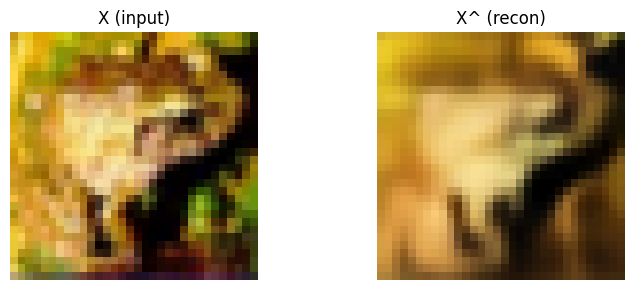

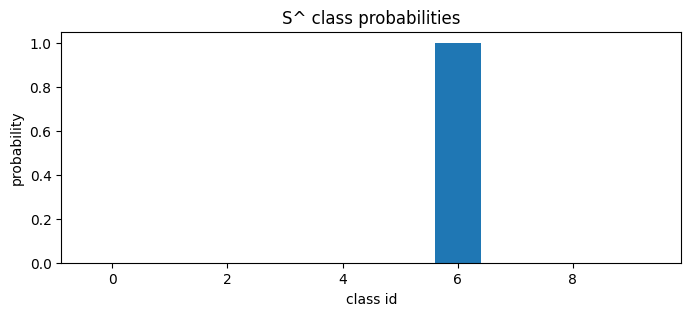

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


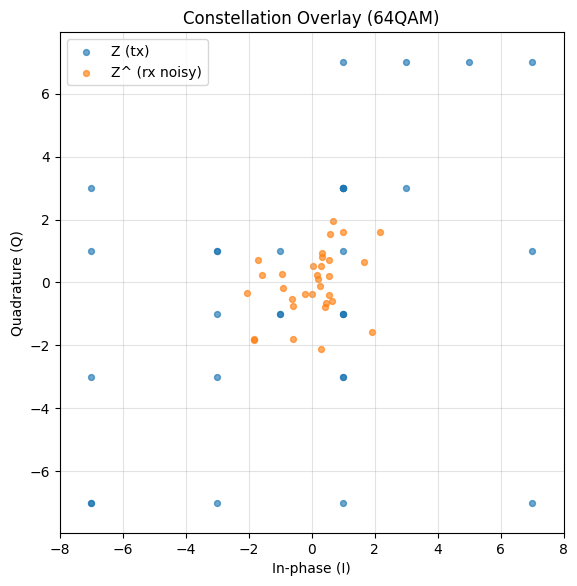

h[0][:10]   = [ 0.2214222   0.7532848   3.0708468   2.416731    1.9420959  -1.5241151
  2.8153841   0.9498143   1.5405867   0.92686176]
q[0,0,:]    = [6.2691129e-19 6.2691129e-19 6.2691129e-19 1.5144534e-16 5.5190180e-10
 4.6440793e-05 5.5365317e-02 9.4458830e-01]
Z[0][:10]   = [ 7.  1.  3. -7.  3.  7.  3.  1.  1.  5.]
Z^[0][:10]  = [ 1.6479774   0.655903    1.3134104  -1.6843927   0.5584682   2.0524743
  0.36289564  0.25733587  0.63019216  1.6291292 ]


In [29]:
# Debug one example through pipeline: X, h, q, Z, Z^, X^, S^, constellation
import inspect
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1) Prepare config/model/checkpoint
config_dbg = make_config(mode="test", mod_method="64qam", pretrain_analog=0, load_checkpoint=1)
config_dbg.mod_method = canonical_mod_method(config_dbg.mod_method)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net_dbg = JCM(config_dbg, device).to(device)
net_dbg.eval()

if config_dbg.load_checkpoint:
    ckpt = './checkpoints/{}/CIFAR_SNR{:.3f}_Trans{:d}_{}.pth.tar'.format(
        config_dbg.mod_method, config_dbg.snr_train, config_dbg.channel_use, config_dbg.mod_method
    )
    net_dbg.load_state_dict(torch.load(ckpt, map_location=device))
    print(f"Loaded checkpoint: {ckpt}")

# 2) Build test loader
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])
test_data = torchvision.datasets.CIFAR10(
    root=config_dbg.dataset_path, train=False, transform=transform_test, download=True
)
test_loader = DataLoader(dataset=test_data, batch_size=config_dbg.batch_size, shuffle=True)

# 3) One batch forward with debug info
X, Y = next(iter(test_loader))
X, Y = X.to(device), Y.to(device)

with torch.no_grad():
    if "return_debug" in inspect.signature(net_dbg.forward).parameters:
        out = net_dbg(X, return_debug=True)
        Z, Z_norm, Z_hat, logits_S_hat, X_hat, dbg = out
        h = dbg['h']
        q = dbg['q']
        S_hat = dbg['s_hat']
    else:
        Z, Z_norm, Z_hat, logits_S_hat, X_hat = net_dbg(X)
        h = net_dbg.encoder(X).reshape(X.shape[0], -1)
        logits = net_dbg.prob_convs(h).reshape(X.shape[0], -1, net_dbg.num_category)
        q = torch.softmax(logits, dim=2)
        S_hat = torch.softmax(logits_S_hat, dim=1)

# 4) Print tensor stats for first sample
idx = 0
print('===== ONE-SAMPLE SHAPES =====')
print('X      :', tuple(X[idx].shape))
print('h      :', tuple(h[idx].shape))
print('q      :', tuple(q[idx].shape))
print('Z      :', tuple(Z[idx].shape))
print('Z^     :', tuple(Z_hat[idx].shape))
print('X^     :', tuple(X_hat[idx].shape))
print('S^     :', tuple(S_hat[idx].shape))

pred_cls = int(torch.argmax(S_hat[idx]).item())
true_cls = int(Y[idx].item())
print(f'True label: {true_cls} | Pred label: {pred_cls}')

# 5) Visualize X and X^
def denorm(img):
    return ((img.detach().cpu() + 1.0) / 2.0).clamp(0, 1)

x_img = denorm(X[idx]).permute(1, 2, 0).numpy()
xhat_img = denorm(X_hat[idx]).permute(1, 2, 0).numpy()

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(x_img)
plt.title('X (input)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(xhat_img)
plt.title('X^ (recon)')
plt.axis('off')
plt.tight_layout()
plt.show()

# 6) Visualize S^ (class probabilities)
plt.figure(figsize=(8, 3))
plt.bar(range(10), S_hat[idx].detach().cpu().numpy())
plt.title('S^ class probabilities')
plt.xlabel('class id')
plt.ylabel('probability')
plt.show()

# 7) Constellation diagram from first mini-batch (with ideal grid)
z_pair = Z[:, :2].detach().cpu().numpy()
zh_pair = Z_hat[:, :2].detach().cpu().numpy()

mod = canonical_mod_method(config_dbg.mod_method)
if mod == 'bpsk':
    levels = [-1, 1]
elif mod == '4qam':
    levels = [-1, 1]
elif mod == '16qam':
    levels = [-3, -1, 1, 3]
elif mod == '64qam':
    levels = [-7, -5, -3, -1, 1, 3, 5, 7]
else:
    levels = []

plt.figure(figsize=(6.5, 6.5))

# ideal constellation points
if len(levels) > 0:
    import numpy as np
    grid_i, grid_q = np.meshgrid(levels, levels)

# measured tx/rx symbols from batch
plt.scatter(z_pair[:, 0], z_pair[:, 1], s=18, alpha=0.65, label='Z (tx)')
plt.scatter(zh_pair[:, 0], zh_pair[:, 1], s=18, alpha=0.65, label='Z^ (rx noisy)')

plt.title(f'Constellation Overlay ({mod.upper()})')
plt.xlabel('In-phase (I)')
plt.ylabel('Quadrature (Q)')
plt.grid(True, alpha=0.35)
plt.legend(loc='best')
plt.axis('equal')

if len(levels) > 0:
    pad = 1.0
    plt.xlim(min(levels) - pad, max(levels) + pad)
    plt.ylim(min(levels) - pad, max(levels) + pad)

plt.show()

# Optional: quick scalar previews
print('h[0][:10]   =', h[idx, :10].detach().cpu().numpy())
print('q[0,0,:]    =', q[idx, 0, :].detach().cpu().numpy())
print('Z[0][:10]   =', Z[idx, :10].detach().cpu().numpy())
print('Z^[0][:10]  =', Z_hat[idx, :10].detach().cpu().numpy())


c:\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Available checkpoints:
  16qam: [-12.0, -6.0, 0.0, 6.0, 12.0, 18.0]
  64qam: [-18.0, -12.0, -6.0, 0.0, 12.0, 18.0]
Selected SNRs:
  16qam: [-12.0, 0.0, 18.0]
  64qam: [-12.0, 0.0, 18.0]


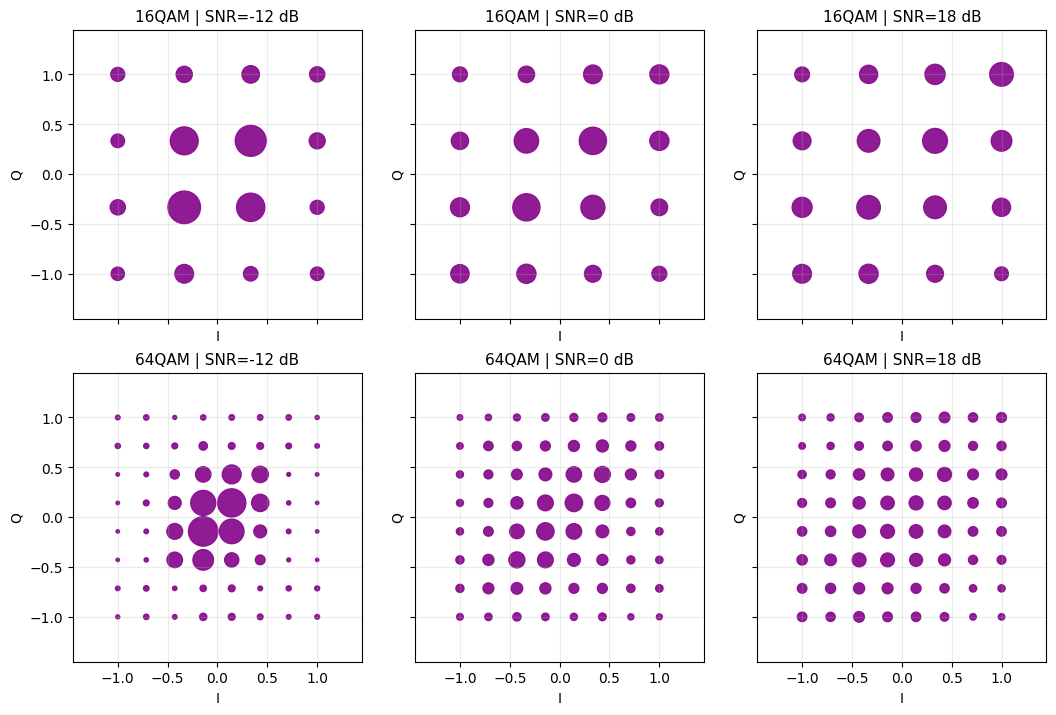

In [32]:
# Paper-style constellation figure with flexible checkpoint selection
import re
from pathlib import Path
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =========================
# User options
# =========================
mods = ["16qam", "64qam"]
num_batches = 10
point_color = "#8a0f8f"

# Mode: "all" (all available checkpoints) or "custom" (use custom_snr_by_mod below)
selection_mode = "custom" # "all" or "custom"

# Used only when selection_mode == "custom"
custom_snr_by_mod = {
    "16qam": [-12, 0, 18],
    "64qam": [-12, 0, 18],
}

# If True, keep a global SNR column set for all rows; missing checkpoints show "no checkpoint"
# If False, each modulation uses only its own selected/available SNRs (more compact plot)
use_union_columns = True

# =========================
# Data loader
# =========================
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])
test_data = torchvision.datasets.CIFAR10(root='./dataset', train=False, transform=transform_test, download=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

def parse_available_snrs(mod):
    d = Path('checkpoints') / mod
    snrs = []
    for f in d.glob(f'*_{mod}.pth.tar'):
        m = re.search(r'CIFAR_SNR(-?\d+\.\d+)_Trans\d+_' + re.escape(mod) + r'\.pth\.tar$', f.name)
        if m:
            snrs.append(float(m.group(1)))
    return sorted(set(snrs))

available_snr_by_mod = {mod: parse_available_snrs(mod) for mod in mods}
print('Available checkpoints:')
for mod in mods:
    print(f'  {mod}: {available_snr_by_mod[mod]}')

# Decide target SNR list per modulation
target_snr_by_mod = {}
for mod in mods:
    if selection_mode == 'all':
        target_snr_by_mod[mod] = available_snr_by_mod[mod]
    else:
        req = [float(v) for v in custom_snr_by_mod.get(mod, [])]
        target_snr_by_mod[mod] = req

print('Selected SNRs:')
for mod in mods:
    print(f'  {mod}: {target_snr_by_mod[mod]}')

# Layout columns
if use_union_columns:
    all_snrs = sorted(set(s for vals in target_snr_by_mod.values() for s in vals))
else:
    all_snrs = None

rows = len(mods)
if use_union_columns:
    cols = max(1, len(all_snrs))
    fig, axes = plt.subplots(rows, cols, figsize=(3.6 * cols, 3.6 * rows), sharex=True, sharey=True)
    if rows == 1:
        axes = [axes]
else:
    # fallback: still create union grid for simpler plotting code
    all_snrs = sorted(set(s for vals in target_snr_by_mod.values() for s in vals))
    cols = max(1, len(all_snrs))
    fig, axes = plt.subplots(rows, cols, figsize=(3.6 * cols, 3.6 * rows), sharex=True, sharey=True)
    if rows == 1:
        axes = [axes]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for r, mod_method in enumerate(mods):
    levels = torch.tensor([-3., -1., 1., 3.]) if mod_method == '16qam' else torch.tensor([-7., -5., -3., -1., 1., 3., 5., 7.])
    I_grid, Q_grid = torch.meshgrid(levels, levels, indexing='ij')
    points = torch.stack([I_grid.reshape(-1), Q_grid.reshape(-1)], dim=1)
    scale = float(levels.abs().max().item())
    points_plot = points / scale

    row_targets = target_snr_by_mod[mod_method]

    for c, snr in enumerate(all_snrs):
        ax = axes[r][c] if rows > 1 else axes[c]

        if snr not in row_targets:
            ax.axis('off')
            continue

        if snr not in available_snr_by_mod[mod_method]:
            ax.set_title(f'{mod_method.upper()} | SNR={snr:g} dB\n(no checkpoint)', fontsize=10)
            ax.grid(True, alpha=0.25)
            ax.set_aspect('equal', adjustable='box')
            ax.set_xlim(-1.45, 1.45)
            ax.set_ylim(-1.45, 1.45)
            ax.set_xlabel('I')
            ax.set_ylabel('Q')
            continue

        config_c = make_config(mode='test', mod_method=mod_method, pretrain_analog=0, load_checkpoint=1)
        config_c.mod_method = canonical_mod_method(config_c.mod_method)
        config_c.snr_train = float(snr)
        config_c.snr_test = float(snr)

        model = JCM(config_c, device).to(device)
        ckpt = './checkpoints/{}/CIFAR_SNR{:.3f}_Trans{:d}_{}.pth.tar'.format(
            config_c.mod_method, config_c.snr_train, config_c.channel_use, config_c.mod_method
        )
        model.load_state_dict(torch.load(ckpt, map_location=device))
        model.eval()

        z_all = []
        with torch.no_grad():
            for bidx, (xb, _) in enumerate(test_loader):
                if bidx >= num_batches:
                    break
                xb = xb.to(device)
                Z, _, _, _, _ = model(xb)
                z_all.append(Z.detach().cpu())

        z = torch.cat(z_all, dim=0).reshape(-1, 2)
        freq = []
        for k in range(points.shape[0]):
            hit = torch.all(z == points[k], dim=1)
            freq.append(hit.float().mean().item())
        freq = torch.tensor(freq)

        size = 6 + 3200 * freq.numpy()
        ax.scatter(points_plot[:, 0].numpy(), points_plot[:, 1].numpy(), s=size, alpha=0.95, color=point_color)
        ax.set_title(f'{mod_method.upper()} | SNR={snr:g} dB', fontsize=11)
        ax.grid(True, alpha=0.25)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(-1.45, 1.45)
        ax.set_ylim(-1.45, 1.45)
        ax.set_xlabel('I')
        ax.set_ylabel('Q')

plt.tight_layout()
plt.show()


In [ ]:
# # Example: train (equivalent to !python main.py --mode train --mod_method 64qam --pretrain_analog 0)
# config = make_config(mode="train", mod_method="64qam", pretrain_analog=0)
# mischandler(config)
# main(config)